In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.options.display.max_columns = None

In [2]:
# Importar librerías
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

/usr/local/lib/python3.9/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [3]:
#mouting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd drive/MyDrive/TFG/oulad

/content/drive/MyDrive/TFG/oulad


In [5]:
df_main = pd.read_csv('df_clean_high_ed.csv')

In [6]:
df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

In [7]:
df_withdraws=df_main.copy()

In [8]:
del df_withdraws['result_aprueba']

In [9]:
df_pass=df_main.copy()

In [10]:
df_pass=df_pass[df_pass['result_stays']==1]

In [11]:
del df_pass['result_stays']

In [12]:
df_pass.result_aprueba.value_counts()

1    142002
0     63558
Name: result_aprueba, dtype: int64

In [13]:
df_withdraws.result_stays.value_counts()

1    205560
0    138024
Name: result_stays, dtype: int64

In [14]:
df_secondary = pd.read_csv('df_clean_low_ed.csv')

In [15]:
df_secondary= df_secondary.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

In [16]:
df_withdraws_2=df_secondary.copy()

In [17]:
del df_withdraws_2['result_aprueba']

In [18]:
df_pass_2=df_secondary.copy()

In [19]:
df_pass_2=df_pass_2[df_pass_2['result_stays']==1]

In [20]:
del df_pass_2['result_stays']

In [21]:
df_pass_2.result_aprueba.value_counts()

1    80496
0    63378
Name: result_aprueba, dtype: int64

In [22]:
df_withdraws_2.result_stays.value_counts()

1    143874
0     99216
Name: result_stays, dtype: int64

In [23]:
# Separar las variables de entrada y la variable de salida
X_large_main = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large_main = df_withdraws.result_stays
X_big_part_main, X_train_main, y_big_part_main, y_train_main = train_test_split(X_large_main, y_large_main, test_size=0.25, random_state=42)

In [24]:
# Separar las variables de entrada y la variable de salida
X_large = df_withdraws_2.loc[:, df_withdraws_2.columns != 'result_stays']
y_large = df_withdraws_2.result_stays
X_big_part, X, y_big_part, y = train_test_split(X_large, y_large, test_size=0.25, random_state=42)

In [25]:
# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, roc_auc_score, f1_score, recall_score, precision_score, accuracy_score, roc_curve, auc
scoring = {'accuracy': 'accuracy', 
           'roc_auc': make_scorer(roc_auc_score), 
           'f1': make_scorer(f1_score),
           'recall': make_scorer(recall_score), 
           'precision': make_scorer(precision_score)}

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'log2', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.8431108158524716
Gradient Boosting - Validation score: 0.7086795557383793
Gradient Boosting - Validation Accuracy: 0.7086795557383793
Gradient Boosting - Test Accuracy: 0.7198683669271905
Gradient Boosting - Validation AUC: 0.6955219060770378
Gradient Boosting - Test AUC: 0.7081075454754171
Gradient Boosting - Validation F1: 0.7566490275582434
Gradient Boosting - Test F1: 0.765220988760946
Gradient Boosting - Validation Recall: 0.7703610411418975
Gradient Boosting - Test Recall: 0.7730565617163555
Gradient Boosting - Validation Precision: 0.7434166103983795
Gradient Boosting - Test Precision: 0.7575426621160409


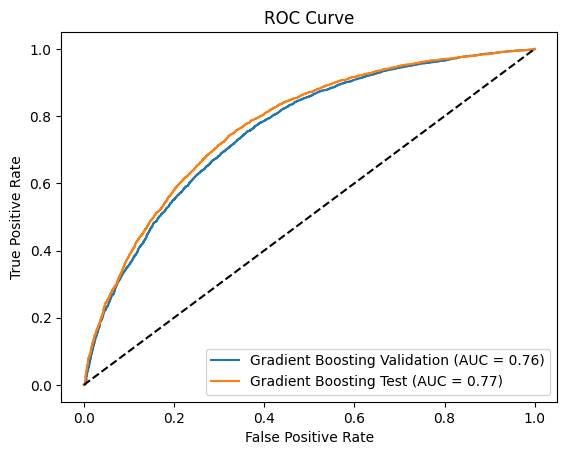

In [27]:
gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train_main, y_train_main)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()